In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
import joblib
from sklearn.model_selection import GridSearchCV

df = pd.read_csv('high_risk_pregnancy_realistic_2000 (1).csv')

In [2]:
x_train_pre = joblib.load('x_train_presplit_smote.pkl')
y_train_pre = joblib.load('y_train_presplit_smote.pkl')
x_test_pre  = joblib.load('x_test_presplit_smote.pkl')
y_test_pre  = joblib.load('y_test_presplit_smote.pkl')

In [3]:
model_pre = LogisticRegression(max_iter=1000, random_state=20)
model_pre.fit(x_train_pre, y_train_pre)
print("Trained Successfully")


Trained Successfully


In [4]:
y_pred_pre = model_pre.predict(x_test_pre)
print(y_pred_pre)


[1 1 0 0 1 0 0 1 1 1 0 0 1 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 1 0
 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 1 1 0 1 0 1 1 0 1 0 1 0 0 1 0 0 1 0 1 0 0
 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1 1 1 0 0 1 0 1 1 1 0 0 0 1 1 1 0 0 1 0 0 1 0
 0 0 1 0 0 0 0 0 0 1 1 0 1 0 1 0 0 1 0 1 0 0 1 1 1 0 1 1 0 0 0 0 1 0 1 0 1
 0 0 0 1 1 1 0 1 0 1 1 0 0 1 1 1 1 0 1 1 1 1 0 1 1 1 0 0 0 0 1 0 0 0 1 0 1
 1 0 1 1 1 1 1 1 1 0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 1
 0 0 0 0 0 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0
 1 1 1 1 1 1 0 0 0 1 0 0 0 1 1 0 0 0 0 1 1 0 1 0 1 0 1 0 1 0 0 0 1 1 0 0 1
 1 1 0 1 1 0 0 1 1 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 1
 1 0 1 0 1 1 0 1 1 0 1 1 0 1 0 0 0 1 1 1 1 0 0 1 1 0 0 0 1 1 0 1 0 0 1 0 0
 0 1 0 1 0 0 0 1 0 0 1 1 1 1 0 1 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 1 0 1 0 0 0
 0 0 1 0 0 1 0 0 1 1 1 0 0 0 1 0 0 1 0 0 1 0 1 0 1 1 1 1 0 0 0 0 0 0 0 0 1
 1 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 1 1 1 1 0 1 1 0 1 0 0
 1 0 0 1 1 0 0 0 0 0 0 0 

In [5]:
y_prob_pre = model_pre.predict_proba(x_test_pre)[:, 1]
print(y_prob_pre)


[0.56109231 0.90242014 0.21400359 0.45517218 0.97407629 0.29597404
 0.02662015 0.98150649 0.54263947 0.89965581 0.25913448 0.31184538
 0.94619562 0.93924956 0.33086603 0.96354301 0.95266869 0.00603174
 0.38292984 0.41869991 0.32707883 0.11345533 0.04948275 0.10555141
 0.10436065 0.02100681 0.28085684 0.95930772 0.45430254 0.28453966
 0.1933785  0.02768493 0.51891074 0.30960661 0.56008801 0.9502563
 0.35551502 0.31696508 0.29065677 0.46209835 0.38288147 0.20150424
 0.30648914 0.07567015 0.21261988 0.7504144  0.93749603 0.42593506
 0.41404634 0.22473518 0.13303367 0.94936923 0.48159903 0.97064026
 0.94681662 0.25052491 0.96846352 0.07581205 0.50359329 0.68868202
 0.36890979 0.94116198 0.25110263 0.5334567  0.01810288 0.3875911
 0.9089324  0.16334004 0.3012903  0.70577081 0.15276758 0.96763037
 0.43593641 0.43286954 0.9748601  0.9760414  0.95886935 0.81397602
 0.92124233 0.65317563 0.89519013 0.24952503 0.34950206 0.583876
 0.11364198 0.38318143 0.603152   0.94612519 0.99519961 0.96798101

In [6]:
print('Accuracy:', accuracy_score(y_test_pre, y_pred_pre))

Accuracy: 0.8217967599410898


In [12]:
print("Classification Report\n")
print(classification_report(y_test_pre, y_pred_pre))

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       339
           1       0.87      0.76      0.81       340

    accuracy                           0.82       679
   macro avg       0.83      0.82      0.82       679
weighted avg       0.83      0.82      0.82       679



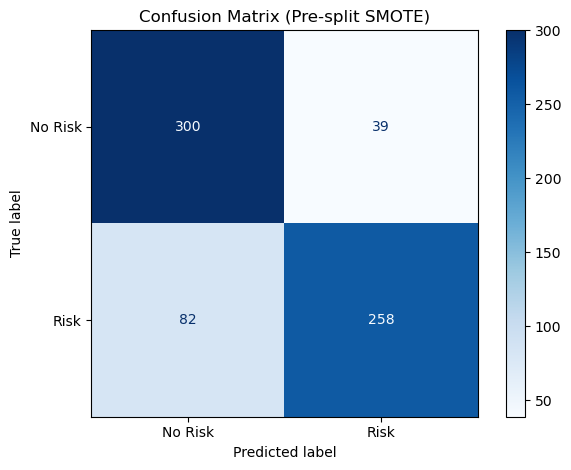

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test_pre, y_pred_pre, display_labels=['No Risk', 'Risk'], cmap='Blues'
)
plt.title("Confusion Matrix (Pre-split SMOTE)")
plt.tight_layout()
plt.show()

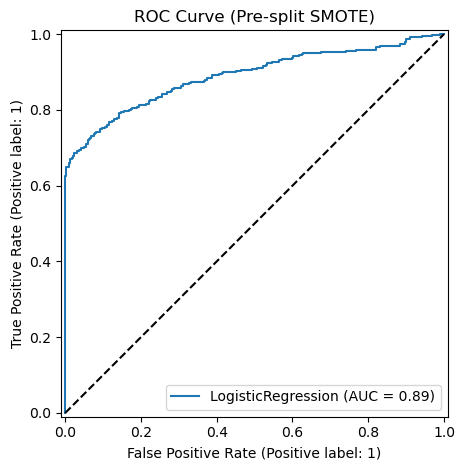

ROC-AUC Score: 0.8892


In [8]:
RocCurveDisplay.from_estimator(model_pre, x_test_pre, y_test_pre)
plt.title('ROC Curve (Pre-split SMOTE)')
plt.plot([0, 1], [0, 1], 'k--')
plt.tight_layout()
plt.show()

print('ROC-AUC Score:', roc_auc_score(y_test_pre, y_prob_pre).round(4))

In [12]:
params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_pre = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params,
    cv=5,
    scoring='roc_auc',
    verbose=1
)


In [13]:
grid_pre.fit(x_train_pre, y_train_pre)

print('Best Parameters:', grid_pre.best_params_)
print('Best AUC Score:', grid_pre.best_score_.round(4))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best AUC Score: 0.8913


In [14]:
best_model_pre = grid_pre.best_estimator_

y_pred_tuned_pre = best_model_pre.predict(x_test_pre)
y_prob_tuned_pre = best_model_pre.predict_proba(x_test_pre)[:, 1]

In [15]:

print('Accuracy after tuning:', round(accuracy_score(y_test_pre, y_pred_tuned_pre), 4))
print('AUC after tuning:', round(roc_auc_score(y_test_pre, y_prob_tuned_pre), 4))

print('===== BEFORE TUNING =====')
print('AUC :', roc_auc_score(y_test_pre, y_prob_pre).round(4))

print('\n===== AFTER TUNING =====')
print('AUC :', roc_auc_score(y_test_pre, y_prob_tuned_pre).round(4))


Accuracy after tuning: 0.8247
AUC after tuning: 0.8893
===== BEFORE TUNING =====
AUC : 0.8892

===== AFTER TUNING =====
AUC : 0.8893


In [16]:
print("Classification Report (Tuned)\n")
print(classification_report(y_test_pre, y_pred_tuned_pre))

Classification Report (Tuned)

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       339
           1       0.87      0.76      0.81       340

    accuracy                           0.82       679
   macro avg       0.83      0.82      0.82       679
weighted avg       0.83      0.82      0.82       679



In [17]:
joblib.dump(best_model_pre, 'logistic_model_presplit_smote.pkl')
print("Model saved!")

joblib.dump(
    list(x_train_pre.columns) if hasattr(x_train_pre, 'columns') else list(range(x_train_pre.shape[1])),
    'feature_names_presplit_smote.pkl'
)
print("Feature names saved!", x_train_pre.shape)

Model saved!
Feature names saved! (2713, 28)
